In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pylab as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import random

#### Aufgabe 1

In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# a) Erzeugen Sie einen moons-Datensatz mit make_moons(n_samples=10000, noise=0.4).
X, y = make_moons(n_samples=10000, noise=0.4, random_state=42)

#b) Teilen Sie ihn mit train_test_split() in einen Trainings- und einen Testdatensatz auf.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [3]:
# c) Versuchen Sie nun, gute Einstellungen für die Hyperparameter eines DecisionTreeClassifier zu finden.
# Hinweis: Probieren Sie unterschiedliche Werte für max_leaf_nodes.

own_tree = DecisionTreeClassifier(max_depth=2, max_leaf_nodes=4)
own_tree.fit(X_train, y_train)
print(own_tree.score(X_test,y_test))

0.856


[[ 0.84441684  1.2423668 ]
 [ 0.16320378  0.82374035]
 [ 1.24805333  0.05579093]
 ...
 [ 0.38876425 -0.78662881]
 [ 2.50492832  0.21133631]
 [ 0.35428745  0.74582457]]
0.856


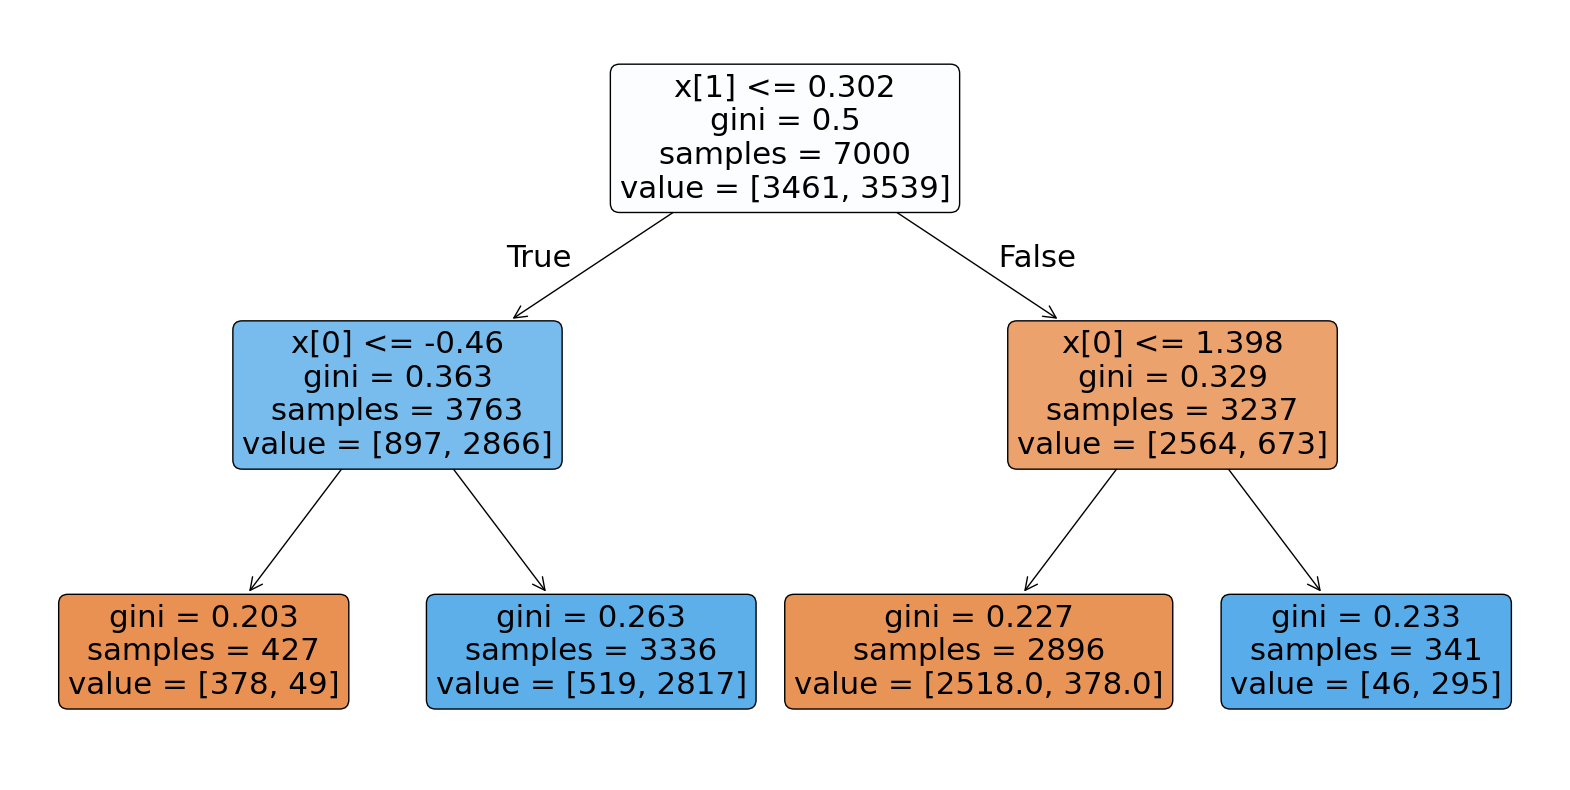

In [4]:
# d) Trainieren Sie den Baum mit den vollständigen Trainingsdaten und bestimmen Sie die Qualität Ihres
# Modells auf den Testdaten. Geben Sie den so trainierten Baum als Graph aus

own_tree_2 = DecisionTreeClassifier(max_depth=3, max_leaf_nodes=4, )
own_tree_2.fit(X_train, y_train)
print(X_train)
y_pred = own_tree_2.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

plt.figure(figsize=(20,10))
plot_tree(own_tree_2, filled=True, rounded=True)
plt.show()

#### Aufgabe 2


wine_tree:  0.9629629629629629


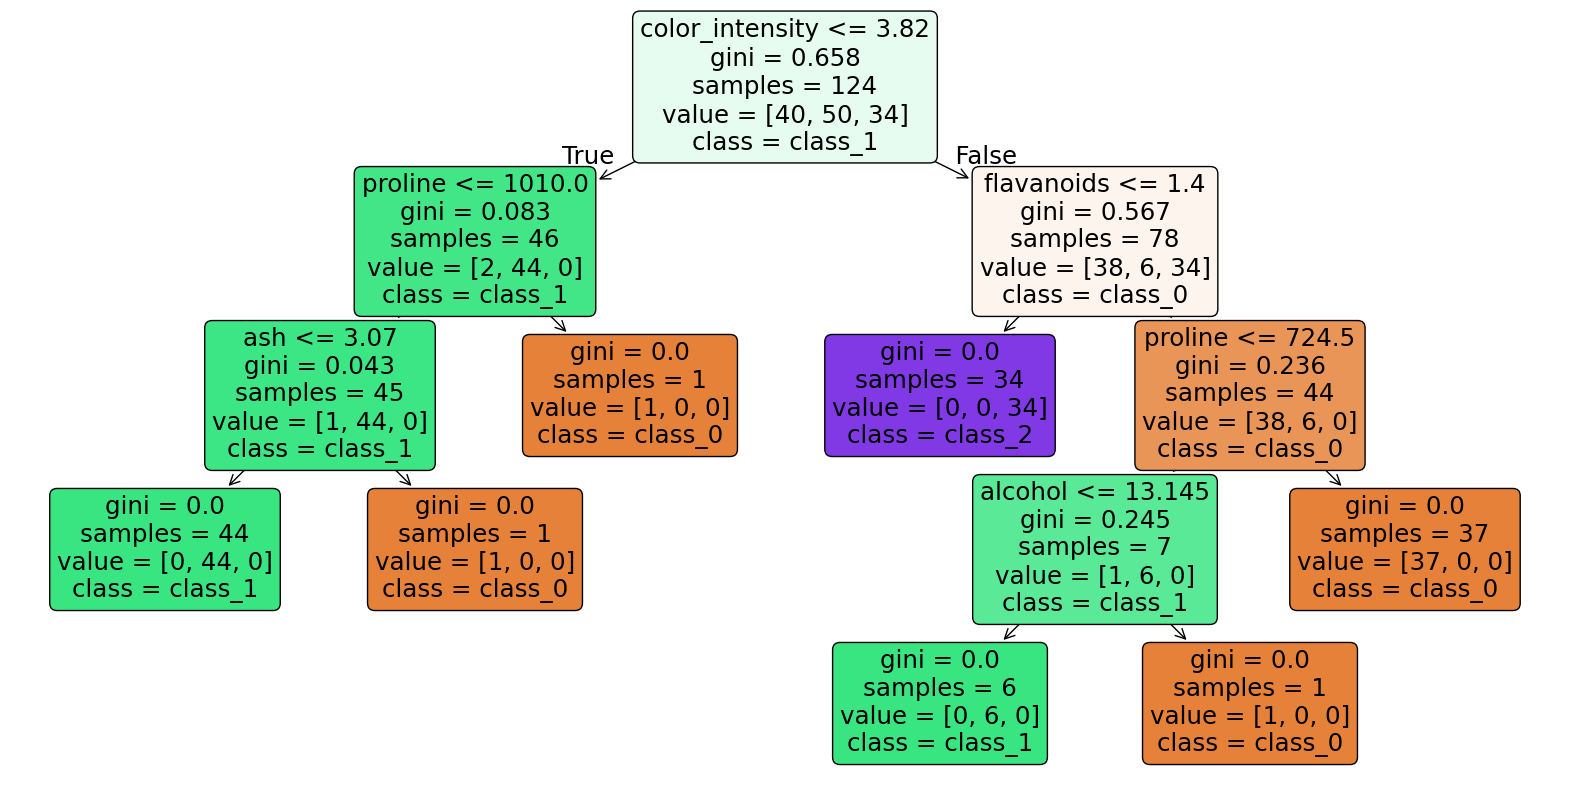

wine_tree_2:  0.9444444444444444
wine_tree_3:  0.8888888888888888


<Figure size 2000x1000 with 0 Axes>

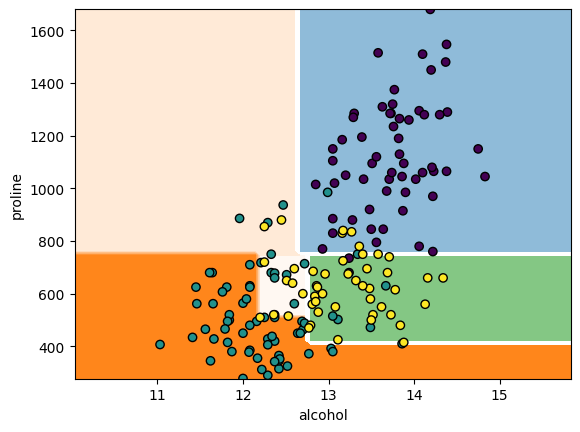

In [ ]:
from sklearn.datasets import load_wine
from sklearn.inspection import DecisionBoundaryDisplay

# a) Wiederholen Sie die Schritte a)-d) der vorigen Aufgabe auf diesem Datensatz.

# 1) Nutzen Sie den Datensatz wine aus scikit-learn.
wine = load_wine()
X,y = load_wine(as_frame=True, return_X_y=True)
X_reduced = X[["alcohol", "proline"]]

# 2) Teilen Sie ihn mit train_test_split() in einen Trainings- und einen Testdatensatz auf.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

# 3) Versuchen Sie nun, gute Einstellungen für die Hyperparameter eines DecisionTreeClassifier zu finden.
wine_tree = DecisionTreeClassifier(max_depth=4, max_leaf_nodes=7)
wine_tree.fit(X_train, y_train)
print("wine_tree: ", wine_tree.score(X_test,y_test))

plt.figure(figsize=(20,10))
plot_tree(wine_tree, filled=True, rounded=True, class_names= wine.target_names, feature_names=X.columns)
plt.show()


# 4) Trainieren Sie den Baum mit den vollständigen Trainingsdaten und bestimmen Sie die Qualität Ihres
wine_tree_2 = DecisionTreeClassifier(max_depth=4, max_leaf_nodes=7)
wine_tree_2.fit(X_train, y_train)
y_pred = wine_tree_2.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("wine_tree_2: ", accuracy)


# b) Plotten Sie die Trennung der beiden Merkmale alcohol und proline mit verschiedenen Hyperparamtern. 
# Was fällt im Vergleich untereinander und zu anderen Klassifikationsalgorithmen auf.
X_train, X_test, y_train, y_test = train_test_split(X_reduced,y, test_size=0.3, random_state=42)
wine_tree_3 = DecisionTreeClassifier(max_depth=4, max_leaf_nodes=7)
wine_tree_3.fit(X_train, y_train)
print("wine_tree_3: ", wine_tree_3.score(X_test,y_test))


plt.figure(figsize=(20, 10))
DecisionBoundaryDisplay.from_estimator(estimator= wine_tree_3, X=X_reduced, xlabel="alcohol", ylabel="proline")
plt.scatter(X_reduced["alcohol"], X_reduced["proline"], c=y, edgecolors='k')
plt.show()

#### Aufgabe 3

Der Hauptunterschied zwischen **`DecisionTreeClassifier`** und **`DecisionTreeRegressor`**  liegt in der Art der Zielvariable, die sie vorhersagen sollen. Während der eine nach "Schubladen" (Klassen) sucht, berechnet der andere "Zahlenwerte" (kontinuierliche Werte).

**1. DecisionTreeClassifier (Klassifikation)** Dieses Modell wird verwendet, wenn das Ziel eine Kategorie oder ein Label ist.

- `Zielvariable`: Diskret (z. B. "Hund", "Katze", "Maus" oder Weinsorten 0, 1, 2).

- `Entscheidungslogik`: Der Baum nutzt die Informationsentropie oder den Gini-Index, um die Unsicherheit in den Daten zu messen. Er versucht, Gruppen zu bilden, die so "rein" wie möglich sind (niedrige Entropie).

- `Output`: Er gibt eine Klasse (also eine Zuordnung der Daten) aus oder mit predict_proba() die Wahrscheinlichkeit für eine Klasse.

- `Visualisierung`: Hier macht der Parameter class_names Sinn, um den Zahlen 0, 1, 2 Namen wie `Riesling` oder `Merlot` zu geben.

**2. DecisionTreeRegressor (Regression)**
Dieses Modell wird verwendet, wenn das Ziel ein numerischer Wert ist.

- `Zielvariable`: Kontinuierlich (z. B. ein Preis, eine Temperatur oder das Ergebnis der Formel y=4(x−0,5)^2).

- `Entscheidungslogik`: Der Regressor nutzt meist den Mean Squared Error (MSE) [Während der Classifier fragt: „Wird die Gruppe dadurch einheitlicher (reiner)?“, fragt der Regressor: „Wird der Fehler (MSE) kleiner?“.]. Er versucht, die Daten so zu teilen, dass der Vorhersagefehler (die Abweichung vom Mittelwert) innerhalb der Endknoten minimal wird.

- `Output`: Er gibt einen konkreten Zahlenwert aus (den Mittelwert aller Trainingspunkte in diesem Blatt).

- `Visualisierung`: Es gibt keine Klassen, daher führt class_names zu einem Fehler. In den Kästchen steht stattdessen value, was dem vorhergesagten Durchschnittswert entspricht.

**3. Was in den Blättern passiert (Der Mittelwert)** Wenn der Baum an einem Endpunkt (Blatt) ankommt, muss er eine Vorhersage treffen.

- `Classifier`: „Die meisten Punkte hier sind Hunde, also sage ich 'Hund' voraus.“

- `Regressor`: „Die y-Werte der Punkte in diesem Bereich sind z. B. 0,8, 0,9 und 1,0. Ich nehme den Durchschnitt und sage 0,9 voraus.“

0.9535383311337664


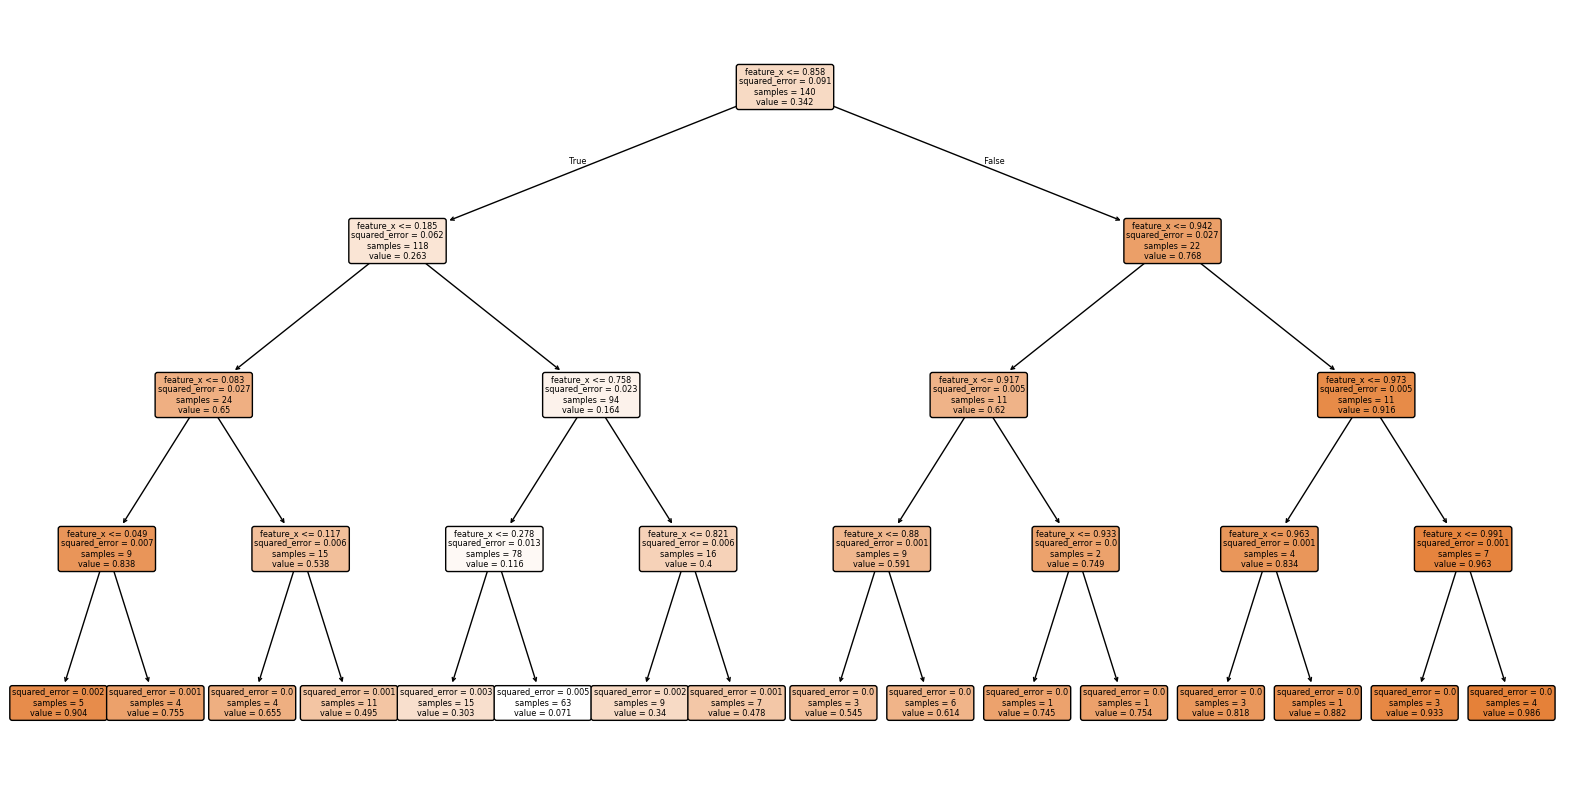

In [ ]:
from sklearn.tree import DecisionTreeRegressor

X =  np.random.rand(200,1)
y = 4*(X-0.5)**2

df = pd.DataFrame(X, columns=['feature_x'])
df['target_y'] = y

# a) Plotten Sie den so erzeugten Datensatz.

# Plot erstellen
'''
plt.figure(figsize=(10, 6))
plt.scatter(df['feature_x'], df['target_y'], color='blue', alpha=0.6, label='Datenpunkte')

# Layout-Einstellungen
plt.title('Plot des Datensatzes: $y = 4(x-0.5)^2$')
plt.xlabel('feature_x (x)')
plt.ylabel('target_y (y)')
plt.show()
'''

# b) Trainieren Sie einen Entscheidungsbaum mit der Methode DecisionTreeRegressor. Variieren Sie dabei den Parameter max_depth.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

number_tree = DecisionTreeRegressor(max_depth=4)
number_tree.fit(X_train, y_train)
print(number_tree.score(X_test, y_test))

# c) Geben Sie die verschiedenen Entscheidungsbäume als Graph aus.
plt.figure(figsize=(20,10))

plot_tree(number_tree, 
          filled=True, 
          rounded=True, 
          feature_names=["feature_x"])

plt.show()


